In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

In [3]:
DP = DP()
dps_df, model_1comp, left_2comp, right_2comp = DP.extract_fits_data('./catalogs/0428_all_test.fits')

In [4]:
print(len(dps_df))

57271


In [5]:
DP_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dps_df['TARGETID'].to_list())

Data loading and processing took 33.42 seconds.


In [ ]:
# example_idx = np.random.choice(len(DP_SPECTRA.targetID))
# example_df = dps_df.iloc[example_idx]
example_id = 39627781725753388
example_df = dps_df[dps_df['TARGETID'] == example_id].iloc[0]
example_idx = DP_SPECTRA.id2index(example_df['TARGETID'])

lam = desi_wavelength / (1 + example_df['Z'])
flux, ivar, mask = DP_SPECTRA.flux[example_idx], DP_SPECTRA.ivar[example_idx], DP_SPECTRA.mask[example_idx]
sigma = 1/np.sqrt(np.abs(ivar))
flux[mask] = np.nan

/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_8087/2261735402.py:9: RuntimeWarning: divide by zero encountered in divide
  sigma = 1/np.sqrt(np.abs(ivar))


In [37]:
example_df

TARGETID        39627763568609564
RA                     178.866531
DEC                     -0.884349
Z                         0.12127
LOGM                    10.524639
                      ...        
BPT_2COMP_L                    16
BPT_2COMP_R                     4
BPT_2COMP                      20
LOGSFR_1COMP            -0.535287
LOGSFR_2COMP            -1.082712
Name: 14413, Length: 78, dtype: object

In [38]:
print(example_df['DV_R']-example_df['DV_L'])

156.42221


In [39]:
test_1comp = model_1comp[example_idx]
test_2comp_l = left_2comp[example_idx]
test_2comp_r = right_2comp[example_idx]
test_2comp = test_2comp_l + test_2comp_r

In [40]:
example_df[['OII3726_FLUX_1COMP', 'OII3729_FLUX_1COMP', 'Hbeta_FLUX_1COMP',
       'OIII4959_FLUX_1COMP', 'OIII5007_FLUX_1COMP', 'NII6548_FLUX_1COMP', 'Halpha_FLUX_1COMP',
       'NII6583_FLUX_1COMP',]]

OII3726_FLUX_1COMP     13.973816
OII3729_FLUX_1COMP     18.599056
Hbeta_FLUX_1COMP       11.167474
OIII4959_FLUX_1COMP      15.8527
OIII5007_FLUX_1COMP     48.01778
NII6548_FLUX_1COMP     18.932949
Halpha_FLUX_1COMP      72.438301
NII6583_FLUX_1COMP     58.057762
Name: 14413, dtype: object

In [41]:
example_df[['OII3726_SNR', 'OII3729_SNR', 'Hbeta_SNR',
       'OIII4959_SNR', 'OIII5007_SNR', 'NII6548_SNR', 'Halpha_SNR',
       'NII6583_SNR',]]

OII3726_SNR          -1.0
OII3729_SNR          -1.0
Hbeta_SNR            -1.0
OIII4959_SNR         -1.0
OIII5007_SNR     6.394479
NII6548_SNR          -1.0
Halpha_SNR      12.137501
NII6583_SNR      7.020119
Name: 14413, dtype: object

In [42]:
example_df[['OII3726_DP', 'OII3729_DP', 'Hbeta_DP',
       'OIII4959_DP', 'OIII5007_DP', 'NII6548_DP', 'Halpha_DP',
       'NII6583_DP',]]

OII3726_DP     False
OII3729_DP     False
Hbeta_DP       False
OIII4959_DP    False
OIII5007_DP    False
NII6548_DP     False
Halpha_DP       True
NII6583_DP      True
Name: 14413, dtype: object

In [43]:
example_df['P_VALUE']

np.float32(1.110223e-16)

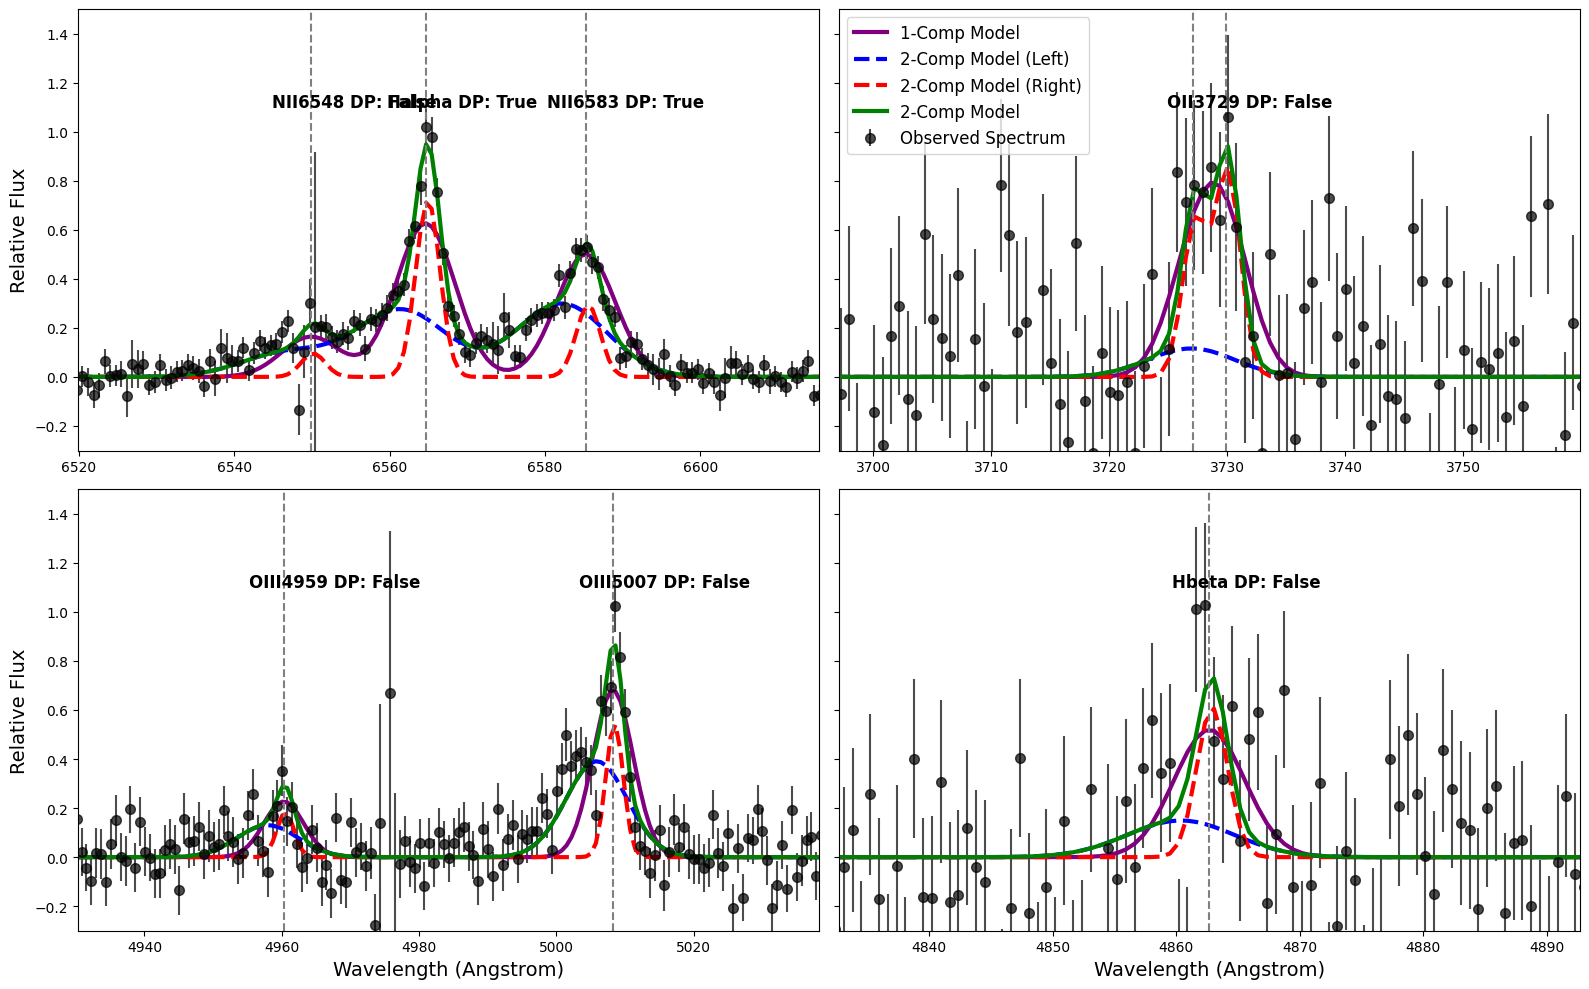

In [44]:
line_cols = ['OII3726', 'OII3729',
            'Hbeta',
            'OIII4959', 'OIII5007',
            'NII6548', 'Halpha', 'NII6583',
            'SII6716', 'SII6731']
lines = [*OII_rest, *Hbeta_rest, *OIII_rest, NII_rest[0], *Halpha_rest, NII_rest[1], *SII_rest]

# plt.figure(figsize=(12,6))

fig, axes = plt.subplots(2, 2, figsize=(16,10), sharey=True)
plt.subplots_adjust(wspace=-0.8)
axes = axes.flatten()

for i, ax in enumerate(axes):

    
    # plt.plot(lam, emission, label='Emission Line Only', color='orange', alpha=0.7)
    # plt.plot(lam, 3*sigma, label=r'3$\sigma$ Limit', color='red', linestyle='--')
    # plt.text(6550, 10, 'test', rotation=90, color='gray', fontsize=8)
    # ax.set_xlabel('Wavelength (Angstrom)')
    # ax.set_ylabel('Flux')
    if i == 0:
        ax.set_xlim([NII_rest[0]-30, NII_rest[1]+30])
        ax.set_ylabel('Relative Flux', fontsize=14)
        lam_mask = ((lam >= NII_rest[0]-40) & (lam <= NII_rest[0]-40+10)) | ((lam <= NII_rest[1]+40) & (lam >= NII_rest[1]+40-10))
    elif i == 1:
        ax.set_xlim([OII_rest[0]-30, OII_rest[1]+30])
        lam_mask = ((lam >= OII_rest[0]-40) & (lam <= OII_rest[0]-40+10)) | ((lam <= OII_rest[1]+40) & (lam >= OII_rest[1]+40-10))
    elif i == 2:
        ax.set_xlim([OIII_rest[0]-30, OIII_rest[1]+30])
        ax.set_xlabel('Wavelength (Angstrom)', fontsize=14)
        ax.set_ylabel('Relative Flux', fontsize=14)
        lam_mask = ((lam >= OIII_rest[0]-40) & (lam <= OIII_rest[0]-40+10)) | ((lam <= OIII_rest[1]+40) & (lam >= OIII_rest[1]+40-10))
    elif i == 3:
        ax.set_xlim([Hbeta_rest[0]-30, Hbeta_rest[0]+30])
        ax.set_xlabel('Wavelength (Angstrom)', fontsize=14)
        lam_mask = ((lam >= Hbeta_rest[0]-40) & (lam <= Hbeta_rest[0]-40+10)) | ((lam <= Hbeta_rest[0]+40) & (lam >= Hbeta_rest[0]+40-10))

    v_max = np.max(flux[(lam>ax.get_xlim()[0]) & (lam<ax.get_xlim()[1])])
    ax.set_ylim(bottom=-0.3, top=1.5)

    
    conti_adj = np.median(flux[lam_mask])
    # conti_adj = 0

    ax.errorbar(lam, (flux-conti_adj)/v_max, yerr=sigma/v_max, label='Observed Spectrum', fmt='o', color='k', markersize=7, alpha=0.7)
    # ax.plot(lam, flux/v_max, color='k', linewidth=2)
    ax.plot(lam, (test_1comp)/v_max, label='1-Comp Model', linewidth=3, color='purple')
    ax.plot(lam, (test_2comp_l)/v_max, label='2-Comp Model (Left)', linestyle='--', linewidth=3, color='blue')
    ax.plot(lam, (test_2comp_r)/v_max, label='2-Comp Model (Right)', linestyle='--', linewidth=3, color='red')
    ax.plot(lam, (test_2comp)/v_max, label='2-Comp Model', linewidth=3, color='green')

    
    for i, line in enumerate(lines):

        if line < ax.get_xlim()[0] or line > ax.get_xlim()[1]:
            continue
        else:
            ax.axvline(x=line, color='gray', linestyle='--')
            if i != 0:
                line_label = f'{line_cols[i]} DP: {example_df[line_cols[i]+'_DP']}'
                if i != 2:
                    ax.text(line-5, 1.1, line_label, color='k', fontsize=12, weight='bold')
                else:
                    ax.text(line-3, 1.1, line_label, color='k', fontsize=12, weight='bold')
            # if i != 0:
            # line_label = f'{line_cols[i]}'
            # if i != 2:
            #     ax.text(line-3, 1.1, line_label, color='k', fontsize=12, weight='bold')
            # else:
            #     ax.text(line-3, 1.1, line_label, color='k', fontsize=12, weight='bold')
axes[1].legend(fontsize=12)

plt.tight_layout()
# plt.savefig(f'./figures/Apr30/{example_df["TARGETID"]}_spectrum.png')
plt.show()


In [45]:
print(image_link(example_df['RA'], example_df['DEC'], plot=False, save_image=False, fname=f"./figures/Apr23/{example_df['TARGETID']}_image_progress.jpg", side_arcmin=0.5))
print(spectrum_link(example_df['TARGETID']))

https://www.legacysurvey.org/viewer?ra=178.8665313720703&dec=-0.8843492865562439&layer=hsc-dr3&zoom=14
https://www.legacysurvey.org/viewer/desi-spectrum/dr1/targetid39627763568609564
